# K-Means Clustering for Stock Returns

This project leverages K-means clustering to group stocks based on historical price movements and key financial indicators. By identifying clusters of similar stocks, we analyze whether these groupings exhibit meaningful differences in their future return distributions. Specifically, we assess the skewness of future returns within each cluster to uncover potential trading signals. A cluster with a highly skewed return distribution may indicate asymmetric risk-reward opportunities, helping traders identify favorable entry and exit points. This approach aims to enhance quantitative trading strategies by integrating unsupervised learning with statistical validation.

### Imports

In [1]:
# import packages

# Data Management
import pandas as pd
import numpy as np
import talib as ta

# For checking stationarity
from statsmodels.tsa.stattools import adfuller

# Data visualisation
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import seaborn as sns

# Importing k-means model
from sklearn.cluster import KMeans

# Import evaluation and interpretation libraries
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from treeinterpreter import treeinterpreter as ti

# Import min-max scaler
from sklearn.preprocessing import MinMaxScaler
from feature_engine.selection import SmartCorrelatedSelection

from unsupervised_learning_quantra import performance_analysis, get_trades, get_analytics

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Data Import

First we import AAPL OHLCV data in 15 min intervals starting at the beginning of 2016

In [2]:
# Data Import
symbol = 'AAPL'
data = pd.read_csv('Apple Prices.csv', index_col=0, parse_dates=True)

In [3]:
data.head()

,close,high,low,open,volume
date,,,,,
2016-01-04 09:45:00,102.70,102.84,102.68,102.78,137361.0
2016-01-04 10:00:00,102.97,102.98,102.83,102.93,166398.0
2016-01-04 10:15:00,103.28,103.39,103.09,103.23,138105.0
2016-01-04 10:30:00,103.51,103.55,103.29,103.35,212347.0
2016-01-04 10:45:00,103.33,103.37,103.26,103.35,117743.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 27918 entries, 2016-01-04 09:45:00 to 2020-05-06 09:45:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   27918 non-null  float64
 1   high    27918 non-null  float64
 2   low     27918 non-null  float64
 3   open    27918 non-null  float64
 4   volume  27918 non-null  float64
dtypes: float64(5)
memory usage: 1.3 MB


A preliminary review of the data reveals no missing values or apparent anomalies.

In [5]:
data.describe()

,close,high,low,open,volume
count,27918.000000,27918.000000,27918.000000,27918.000000,2.791800e+04
mean,172.970988,173.051757,172.883229,172.970878,7.999529e+04
std,55.738135,55.780509,55.691978,55.738360,1.133586e+05
min,89.740000,89.840000,89.720000,89.790000,0.000000e+00
25%,121.980000,122.000000,121.970000,121.982500,2.891700e+04
50%,170.600000,170.665000,170.530000,170.605000,4.837650e+04
75%,204.377500,204.520000,204.280000,204.367500,8.458250e+04
max,327.330000,327.755000,327.160000,327.750000,2.550960e+06


There are 14 rows where the volume is recorded as zero. This could be due to missing data, with the data vendor substituting zero in place of null values. However, since we plan to drop the volume data later, this will not impact our analysis.

In [6]:
zero_volume_count = (data["volume"] == 0).sum()
print(f"Number of rows with zero volume: {zero_volume_count}")

Number of rows with zero volume: 14


Visualizing the OHLCV data also reveals no apparent anomalies.

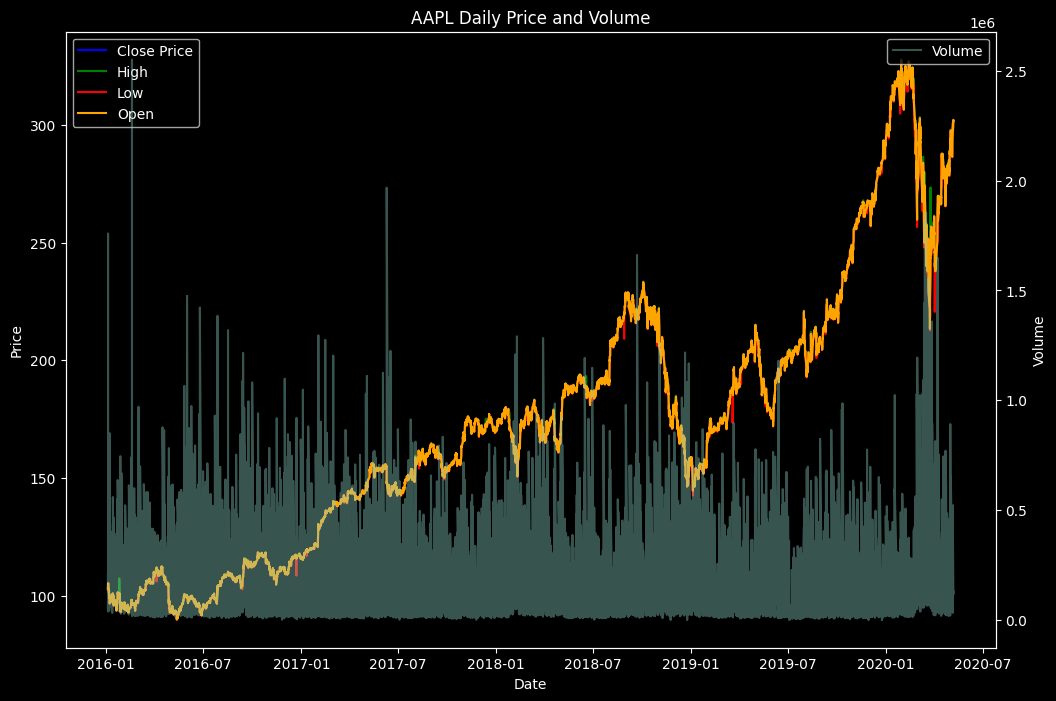

In [7]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot the price data on the first y-axis (ax1)
ax1.plot(data['close'], label='Close Price', color='blue')
ax1.plot(data['high'], label='High', color='green')
ax1.plot(data['low'], label='Low', color='red')
ax1.plot(data['open'], label='Open', color='orange')

# Set labels and title for the first y-axis
ax1.set_title(f'{symbol} Daily Price and Volume')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# Add legend for the price data
ax1.legend(loc='upper left')

# Create a second y-axis for the volume data
ax2 = ax1.twinx()

# Plot the volume on the second y-axis (ax2)
ax2.plot(data['volume'], label='Volume', alpha=0.4)

# Set the y-axis label for volume
ax2.set_ylabel('Volume')

# Add legend for the volume data
ax2.legend(loc='upper right')

# Show the plot
plt.show()

### Feature Engineering and Selection

Next, we incorporate features to capture returns over time, as well as measures of volatility, momentum, and trend strength.

In [8]:
# Calculating returns
data['pct_change'] = data['close'].pct_change()

# Calculating 3.75 hours of return
data['ret375_hours'] = data['close'].pct_change(15)

# Calculating 14-day returns
data['ret14_days'] = data['close'].pct_change(int(6.5 * 4 * 14))

# Calculating 1-day SMA
data['SMA'] = (data['close'].rolling(window=int(6.5 * 4)).mean())

# Calculating 1-day volatility
data['Volatility'] = data['pct_change'].rolling(window=int(6.5 * 4)).std() * 100

# Calculating 14-day volatility
data['Volatility14'] = data['pct_change'].rolling(window=int(6.5 * 4 * 14)).std() * 100

# Calculating 1-day RSI
data['RSI'] = ta.RSI(np.array(data['close']), timeperiod=int(6.5*4))

# Calculating 1-day ADX
data['ADX'] = ta.ADX(data['high'], data['low'], data['close'], timeperiod=int(6.5*4))

# Compute MACD 
_, _, data["MACD_Hist"] = ta.MACD(data["close"], fastperiod=12, slowperiod=26, signalperiod=9)

In [9]:
df = data.copy()
df.drop(columns=["close", "open", "high", "low", "volume", "pct_change"], inplace=True)
df.dropna(inplace=True)
df.head()

,ret375_hours,ret14_days,SMA,Volatility,Volatility14,RSI,ADX,MACD_Hist
date,,,,,,,,
2016-01-25 10:30:00,0.004794,-0.020351,100.336923,0.331258,0.470882,58.477396,18.946288,-0.110480
2016-01-25 10:45:00,0.006791,-0.020977,100.388846,0.316151,0.470793,59.476186,18.875192,-0.118417
2016-01-25 11:00:00,0.001296,-0.027208,100.440000,0.316900,0.470840,57.049982,18.705719,-0.144712
2016-01-25 11:15:00,-0.000298,-0.028113,100.482692,0.311382,0.470740,57.735560,18.610082,-0.150811
2016-01-25 11:30:00,-0.001293,-0.028162,100.531154,0.305410,0.470745,56.438291,18.419618,-0.163372


Now, we assess the stationarity of the features. Stationarity implies that a feature maintains a constant mean and variance over time, a crucial property for machine learning models.

In [10]:
# Checking for stationarity
def stationary(series):
    """
    Function to check if the series is stationary or not.
    """
    result = adfuller(series)
    if(result[1] < 0.05):
        return 'stationary'
    else:
        return 'not stationary'


# non-stationary features
non_stationary = []
for col in df.columns:
    if stationary(df[col]) == 'not stationary':
        print('%s is not stationary.' % col)
        non_stationary.append(col)
    else:
        print('%s is stationary.' % col)

ret375_hours is stationary.
ret14_days is stationary.
SMA is not stationary.
Volatility is stationary.
Volatility14 is stationary.
RSI is stationary.
ADX is stationary.
MACD_Hist is stationary.


For any non-stationary features, we will apply differencing to transform them into a stationary series.

In [11]:
# Apply differencing
for col in non_stationary :
    df[f'{col}_diff'] = df[col] - df[col].shift(1)

In [12]:
df.dropna(inplace=True)
df.head()

,ret375_hours,ret14_days,SMA,Volatility,Volatility14,RSI,ADX,MACD_Hist,SMA_diff
date,,,,,,,,,
2016-01-25 10:45:00,0.006791,-0.020977,100.388846,0.316151,0.470793,59.476186,18.875192,-0.118417,0.051923
2016-01-25 11:00:00,0.001296,-0.027208,100.440000,0.316900,0.470840,57.049982,18.705719,-0.144712,0.051154
2016-01-25 11:15:00,-0.000298,-0.028113,100.482692,0.311382,0.470740,57.735560,18.610082,-0.150811,0.042692
2016-01-25 11:30:00,-0.001293,-0.028162,100.531154,0.305410,0.470745,56.438291,18.419618,-0.163372,0.048462
2016-01-25 11:45:00,-0.000696,-0.024750,100.573846,0.303619,0.470522,56.774984,18.282349,-0.163635,0.042692


We will now re-evaluate stationarity and remove any features that remain non-stationary.

In [13]:
# Checking for stationarity
def stationary(series):
    """
    Function to check if the series is stationary or not.
    """
    result = adfuller(series)
    if(result[1] < 0.05):
        return 'stationary'
    else:
        return 'not stationary'


# Remove non-stationary features
for col in df.columns:
    if stationary(df[col]) == 'not stationary':
        print('%s is not stationary. Dropping it.' % col)
        df.drop(columns=[col], axis=1, inplace=True)
    else:
        print('%s is stationary.' % col)

ret375_hours is stationary.
ret14_days is stationary.
SMA is not stationary. Dropping it.
Volatility is stationary.
Volatility14 is stationary.
RSI is stationary.
ADX is stationary.
MACD_Hist is stationary.
SMA_diff is stationary.


Next, we will evaluate the correlation between features. High correlation can result in multicollinearity, which may affect the reliability of calculations in machine learning models.

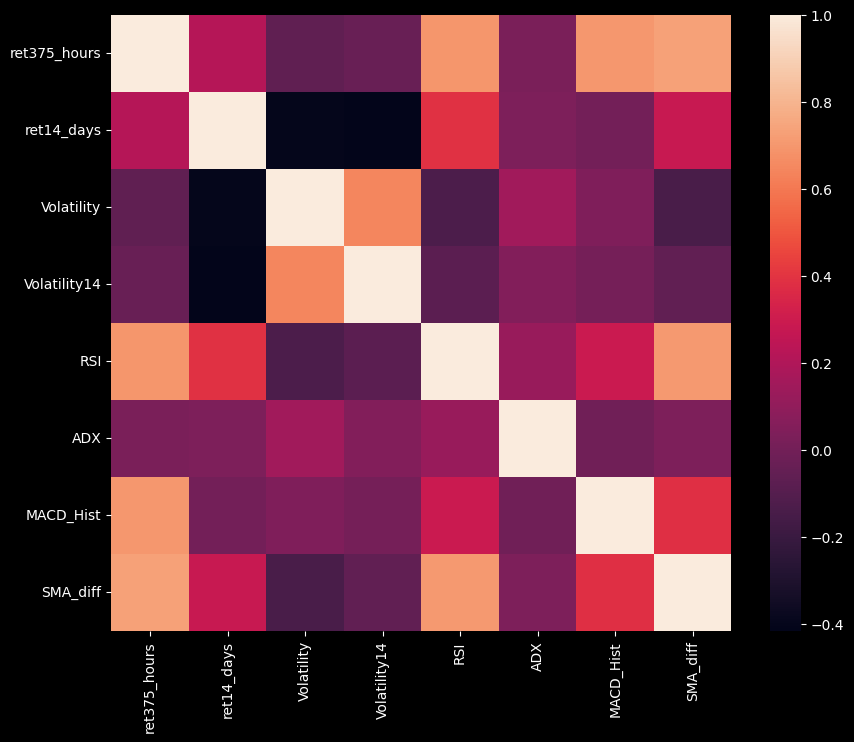

In [14]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix)
plt.show()

We will split the data into training and test sets before removing highly correlated features to prevent data leakage and ensure the model is evaluated on unseen data.

In [15]:
# Split and get features_train and features_test
split = int(len(df) * 0.75)
features_train, features_test = df[:split], df[split:]

print("Features training data set shape          : ", features_train.shape)
print("Features test data set shape              : ", features_test.shape)

# Slicing apple_prices to get apple_prices_train and apple_prices_test
df_train, df_test = df[:split], df[split:]

print(f"{symbol} prices train data set shape: ", df_train.shape)
print(f"{symbol} prices test data set shape : ", df_test.shape)

Features training data set shape          :  (20664, 8)
Features test data set shape              :  (6889, 8)
AAPL prices train data set shape:  (20664, 8)
AAPL prices test data set shape :  (6889, 8)


Using the SmartCorrelatedSelection method from the Feature Engine library, we will remove features with a correlation above 0.75 and retain the feature with the higher variance.

In [16]:
sel = SmartCorrelatedSelection(variables = ['ret14_days', 'Volatility', 'RSI', 'ADX', 'SMA_diff'],
                               threshold=0.75, 
                               selection_method='variance').fit(df_train)

# correlated variables
sel.correlated_feature_sets_

[{'RSI', 'SMA_diff'}]

In [17]:
# Retain variable with highest variability from each group

df_train = sel.transform(df_train)
df_test = sel.transform(df_test)

df_train.shape, df_test.shape

((20664, 7), (6889, 7))

We are now left with the selected features that will be used for the K-Means model.

In [18]:
df_train.head()

,ret375_hours,ret14_days,Volatility,Volatility14,RSI,ADX,MACD_Hist
date,,,,,,,
2016-01-25 10:45:00,0.006791,-0.020977,0.316151,0.470793,59.476186,18.875192,-0.118417
2016-01-25 11:00:00,0.001296,-0.027208,0.316900,0.470840,57.049982,18.705719,-0.144712
2016-01-25 11:15:00,-0.000298,-0.028113,0.311382,0.470740,57.735560,18.610082,-0.150811
2016-01-25 11:30:00,-0.001293,-0.028162,0.305410,0.470745,56.438291,18.419618,-0.163372
2016-01-25 11:45:00,-0.000696,-0.024750,0.303619,0.470522,56.774984,18.282349,-0.163635


Next, we scale the data using the Min-Max Scaler to ensure all features are on the same scale, which helps improve the performance and stability of machine learning models.

In [19]:
# Fit MinMaxScaler on X_train
scaler = MinMaxScaler().fit(df_train)

# Scale X_train using the `scaler` initialised above
df_train = pd.DataFrame(scaler.transform(
    df_train), columns=df_train.columns, index=df_train.index)

# Scale X_test using the `scaler` initialised above
df_test = pd.DataFrame(scaler.transform(
    df_test), columns=df_test.columns, index=df_test.index)

### Modeling

Next, we initialize a K-Means model with 2 clusters and examine its WCSS (within-cluster sum of squares) or Inertia. WCSS measures the sum of squared distances between points and their respective cluster centroids. We will then plot the WCSS for up to 30 clusters. As the number of clusters increases, the WCSS will always decrease and eventually reach zero when each point forms its own cluster. However, this would lead to overfitting and is not useful. Our goal is to choose the number of clusters at the point where the WCSS stops decreasing significantly, indicating an optimal balance between model complexity and fit.

In [20]:
# Initialise the model with 2 clusters
model = KMeans(n_clusters=2, random_state=40)

# Fit the model to create 2 clusters
model.fit(df_train)

# Get inertia
round(model.inertia_, 2)

1974.27

In [21]:
# Define a function to fit and return the k-means model inertia
def fit_kmeans(num_clusters, dataframe):
    """
    This function takes the features dataframe, number of clusters and returns 
    the inertia of the fitted model.
    """
    model = KMeans(n_clusters=num_clusters, random_state=40)
    model.fit(dataframe)
    return model.inertia_


# Defining a dataframe to store WCSS for different number of clusters
wcss_df = pd.DataFrame({
    "Number of Clusters": [num for num in range(1, 31)],
    "WCSS": np.nan
})

# Calculating WCSS for number of clusters ranging from 1 to 30
wcss_df["WCSS"] = wcss_df["Number of Clusters"].apply(
    fit_kmeans, args=(df_train, ))

wcss_df.head(10)

,Number of Clusters,WCSS
0,1,2685.800257
1,2,1974.267081
2,3,1557.858654
3,4,1367.726002
4,5,1253.961727
5,6,1123.866239
6,7,1042.436962
7,8,972.648721
8,9,943.226932
9,10,901.238319


Upon examining the plot of WCSS against the number of clusters, we observe that the trend starts to flatten between 7 and 12 clusters, indicating a point of diminishing returns where adding more clusters no longer significantly improves the model.

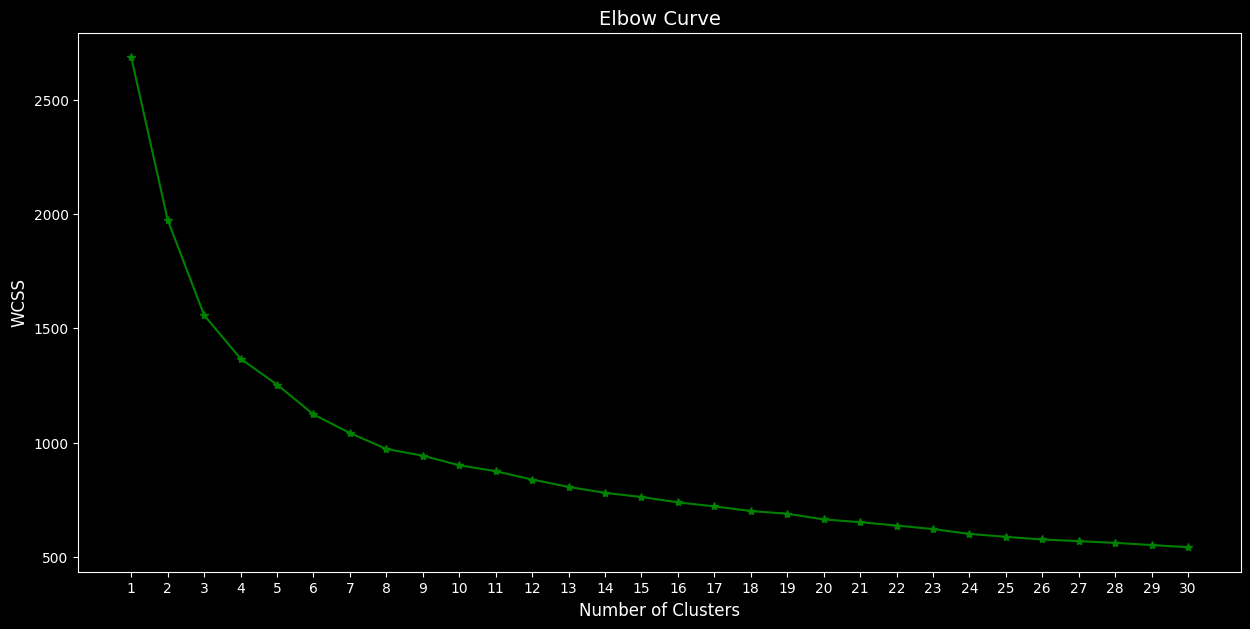

In [22]:
# Plotting the elbow curve
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
ax.set_xticks(wcss_df["Number of Clusters"])
ax.plot(wcss_df["Number of Clusters"], wcss_df["WCSS"], 'g*-')
ax.set_xlabel("Number of Clusters", fontsize=12)
ax.set_ylabel("WCSS", fontsize=12)
ax.set_title("Elbow Curve", fontsize=14);

To better understand the change, we will plot the variation in WCSS across different numbers of clusters. This allows us to observe that after 9 clusters, the trend becomes nearly flat, indicating that additional clusters no longer contribute significantly to reducing the WCSS.

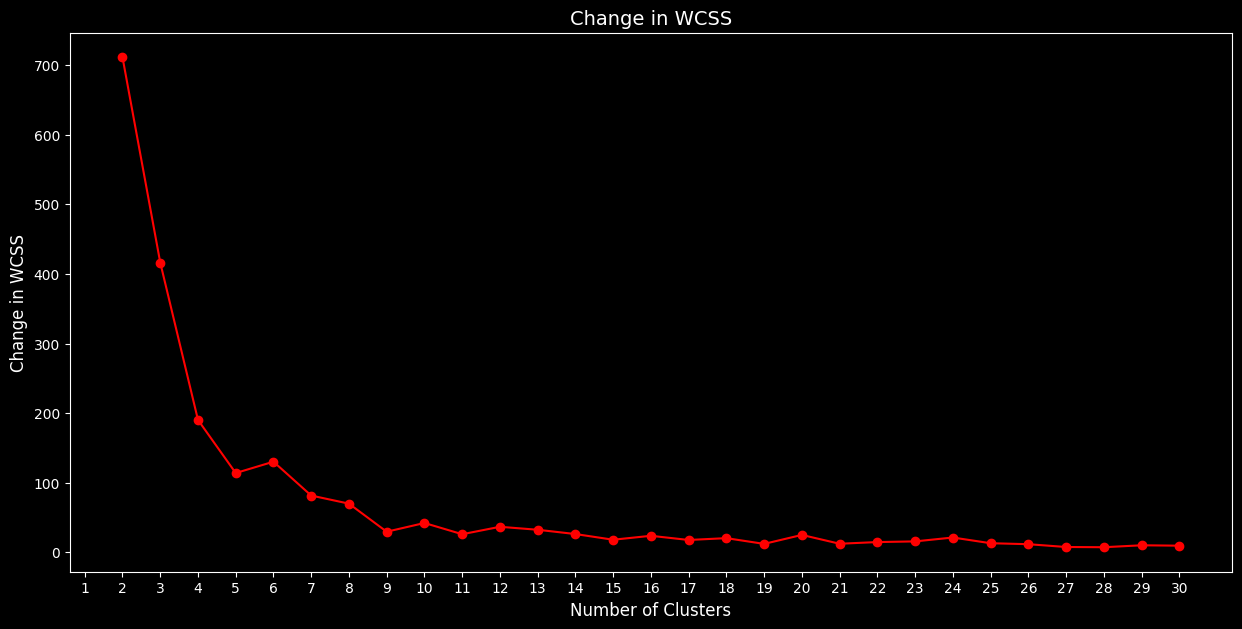

In [23]:
# Calculating change in WCSS
wcss_df["Change in WCSS"] = wcss_df["WCSS"].diff().abs()

# Plotting the change in WCSS
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
ax.set_xticks(wcss_df["Number of Clusters"])
ax.plot(wcss_df["Number of Clusters"], wcss_df["Change in WCSS"], 'ro-')
ax.set_xlabel("Number of Clusters", fontsize=12)
ax.set_ylabel("Change in WCSS", fontsize=12)
ax.set_title("Change in WCSS", fontsize=14);

We will convert the percentage change in WCSS into percentiles and establish a threshold value to serve as a cutoff point. This will help us identify the number of clusters where the change in WCSS becomes negligible and stabilizes.

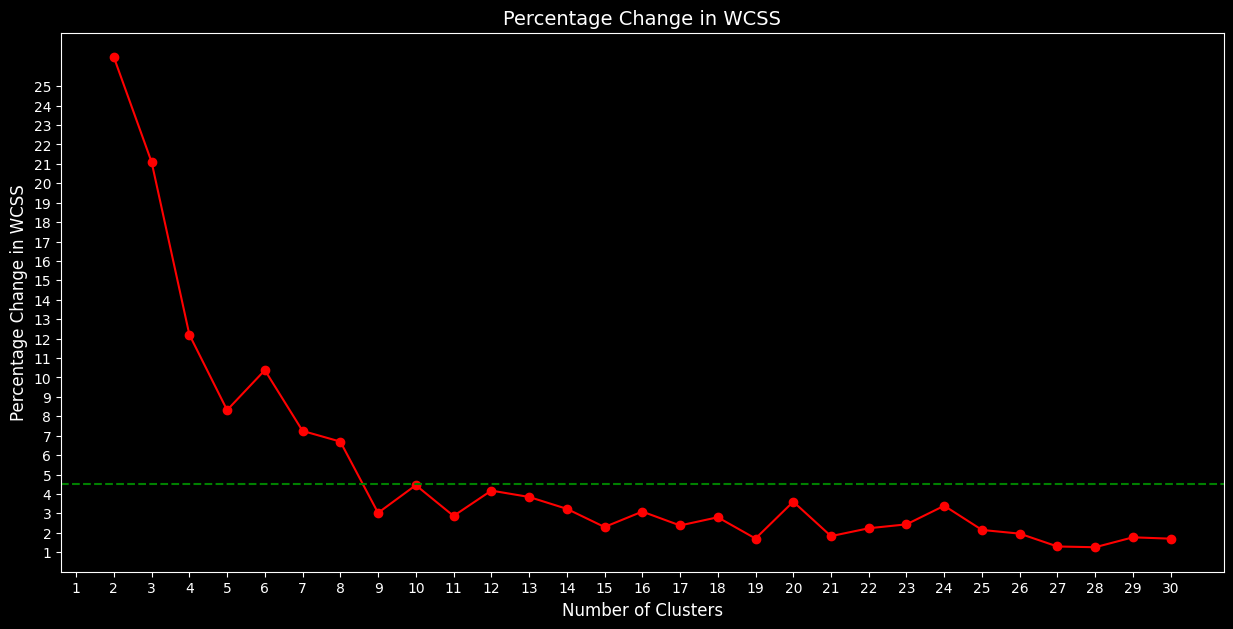

In [24]:
# Calculating percentage change in WCSS
wcss_df["pct_change"] = wcss_df["WCSS"].pct_change().abs()*100

# Defining threshold value
threshold = 4.5

# Plotting percentage change in WCSS
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
ax.set_xticks(wcss_df["Number of Clusters"])
ax.set_yticks([_ for _ in range(1, 26)])
ax.plot(wcss_df["Number of Clusters"], wcss_df["pct_change"], 'ro-')
ax.axhline(threshold, color='g', linestyle="--")
ax.set_xlabel("Number of Clusters", fontsize=12)
ax.set_ylabel("Percentage Change in WCSS", fontsize=12)
ax.set_title("Percentage Change in WCSS", fontsize=14);

We will create a function that automatically calculates the optimal number of clusters based on a threshold for the percentage change in WCSS. This will help identify the point where the decrease in WCSS becomes negligible, and the number of clusters starts to stabilize. 

In [25]:
def get_number_of_clusters(features, threshold=threshold, max_range=30):
    """
    Function to get the number of clusters where the percentage change in WCSS 
    becomes lower than the threshold.
    """
    # Defining a dataframe to store WCSS for different number of clusters
    wcss_df = pd.DataFrame({
        "Number of Clusters": [num for num in range(1, max_range + 1)],
        "WCSS": np.nan
    })

    # Calculating WCSS or inertia for number of clusters
    wcss_df["WCSS"] = wcss_df["Number of Clusters"].apply(lambda inertia: (
        KMeans(n_clusters=inertia, random_state=40).fit(features)).inertia_)

    # Calculating percentage change in WCSS
    wcss_df["pct_change"] = wcss_df["WCSS"].pct_change().abs()*100

    # Returning number of clusters where percentage change goes below
    # the threshold
    num_clusters = wcss_df[wcss_df["pct_change"] <
                           threshold].iloc[0]["Number of Clusters"]

    return int(num_clusters)


# Calling the function
num_clusters = get_number_of_clusters(df_train, threshold)

print("Number of clusters: ", num_clusters)

Number of clusters:  9


Now we will make a model with 9 clusters.

In [26]:
# Initialising the k-means model with 10 clusters
model = KMeans(n_clusters=num_clusters, random_state=42)

# Fitting the k-means model on the features in apple_prices_train
model.fit(df_train)

# Getting the cluster for each observation in the train data set
c_train = model.predict(df_train)

# Getting the cluster for each observation in the test data set
c_test = model.predict(df_test)

By examining the percentage distribution of data across the clusters, we can observe that approximately 22.3% of the data points are in cluster 0, 15.9% in cluster 5, 11.8% in cluster 4, and so on.

In [27]:
pd.Series(c_train).value_counts(normalize=True)

0    0.223480
5    0.159359
4    0.118031
8    0.112321
6    0.106078
3    0.094415
7    0.093883
2    0.055023
1    0.037408
Name: proportion, dtype: float64

### Interpretation with a Decision Tree Surrogate Model

Using a decision tree as a surrogate for interpreting a K-means model is beneficial because K-means, being a clustering algorithm, doesn't provide direct interpretability in terms of feature importance or decision-making processes. A decision tree, on the other hand, creates clear, hierarchical rules based on feature thresholds, making it easier to understand the decision boundaries between clusters.

By fitting a decision tree on the cluster labels generated by K-means, you can identify which features most influence the formation of the clusters. This approach provides insights into why certain data points are grouped together, allowing for better interpretation of the model's behavior and increasing trust in the clustering results.

In [28]:
# Train a surrogate to predict the cluster
# to which an observation will be allocated

surrogate = DecisionTreeClassifier(max_depth=4, random_state=42)

surrogate.fit(df_train, c_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

By plotting the decision tree, we can observe how the surrogate model made its splits. While the plot might be difficult to read directly within the Jupyter notebook, it still provides a general sense of the decision-making process. The first split occurred based on `Volatility14 <= 0.284`, followed by `RSI <= 0.56` on the left branch and `ret14 <= 0.604` on the right, with subsequent splits continuing similarly.

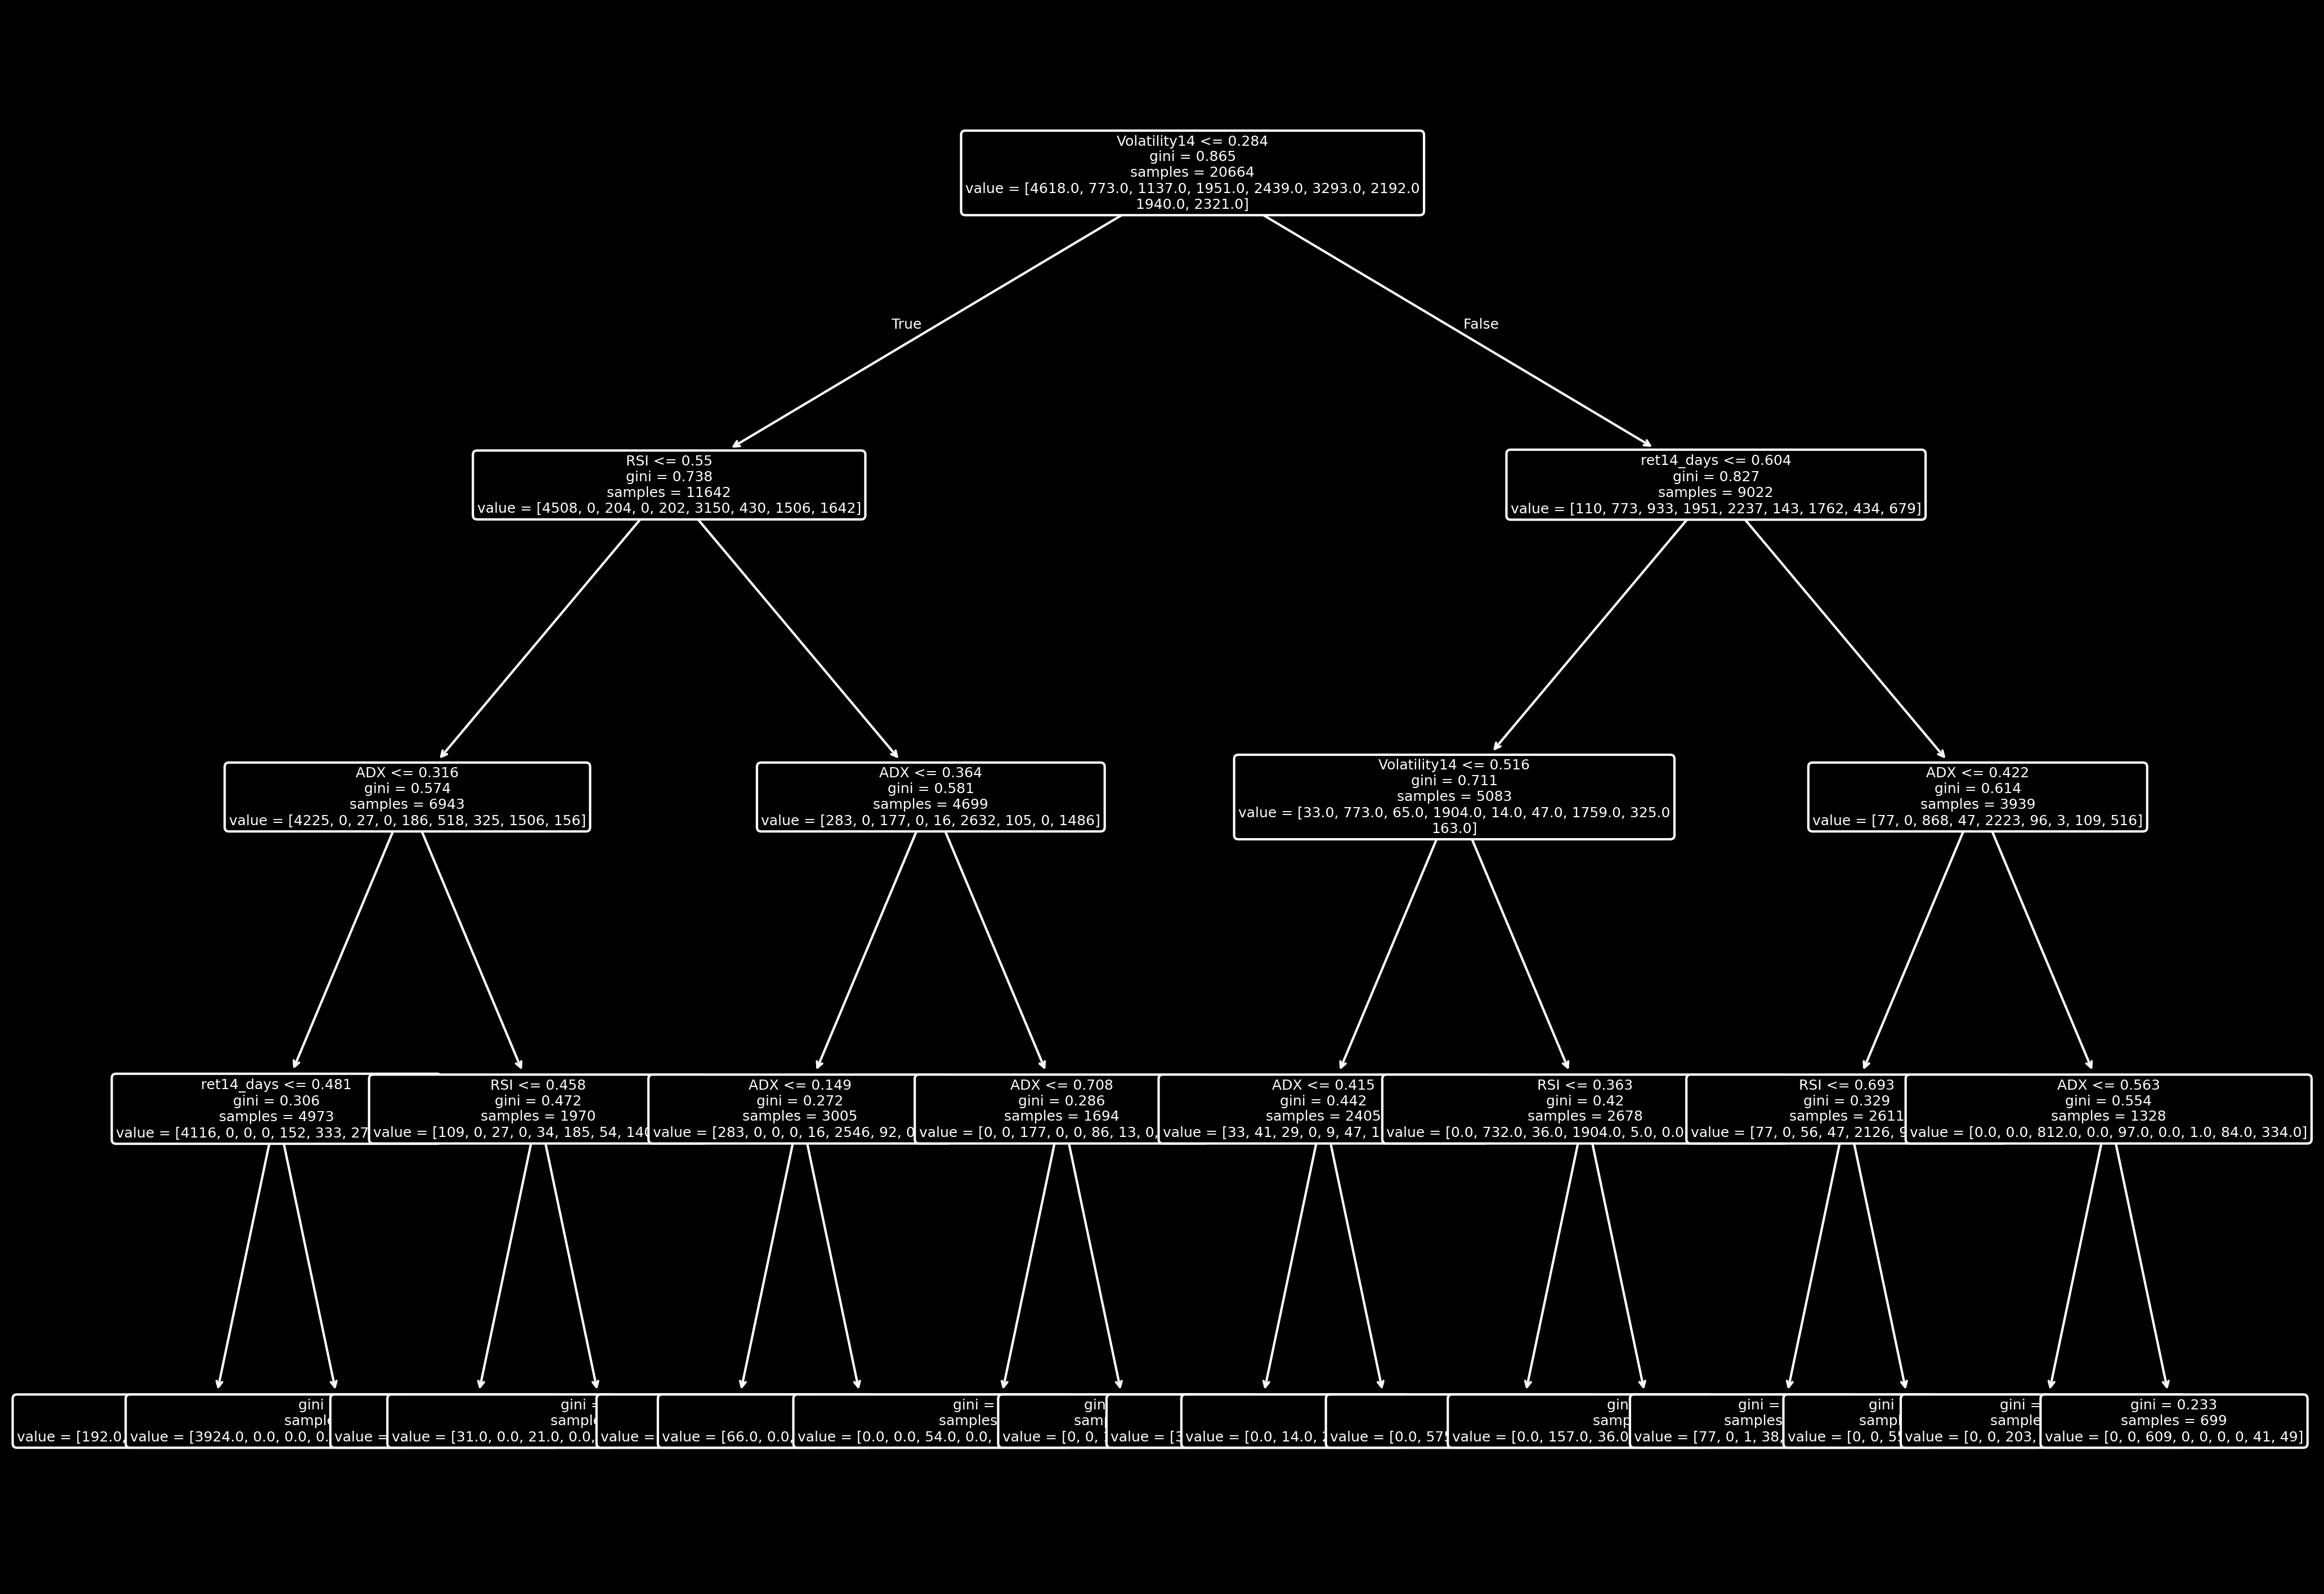

In [29]:
plt.figure(figsize=(16, 12), dpi=300)

plot_tree(
    decision_tree=surrogate,
    feature_names=df_train.columns.to_list(),
    filled=False,         # Color the squares
    rounded=True,        # Round squares
    fontsize=6,         # Set the font size of the text
)

plt.show()

The decision tree model shows some signs of overfitting, as reflected by the higher accuracy on the training set (82.5%) compared to the test set (71.9%). However, our primary goal here is to gain insight into the decision boundaries between the clusters, rather than optimizing for predictive accuracy.

In [30]:
print(f"Accuracy in train set: {accuracy_score(c_train, surrogate.predict(df_train))}")
print(f"Accuracy in test set: {accuracy_score(c_test, surrogate.predict(df_test))}")

Accuracy in train set: 0.824961285327139
Accuracy in test set: 0.7194077514878793


Using the feature_importances_ attribute, we can observe that `ADX` is the most influential feature in the model, followed by `Volatility14`, `RSI`, and `ret14_days`. The remaining features have minimal impact on the decision-making process, as indicated by their negligible importance.

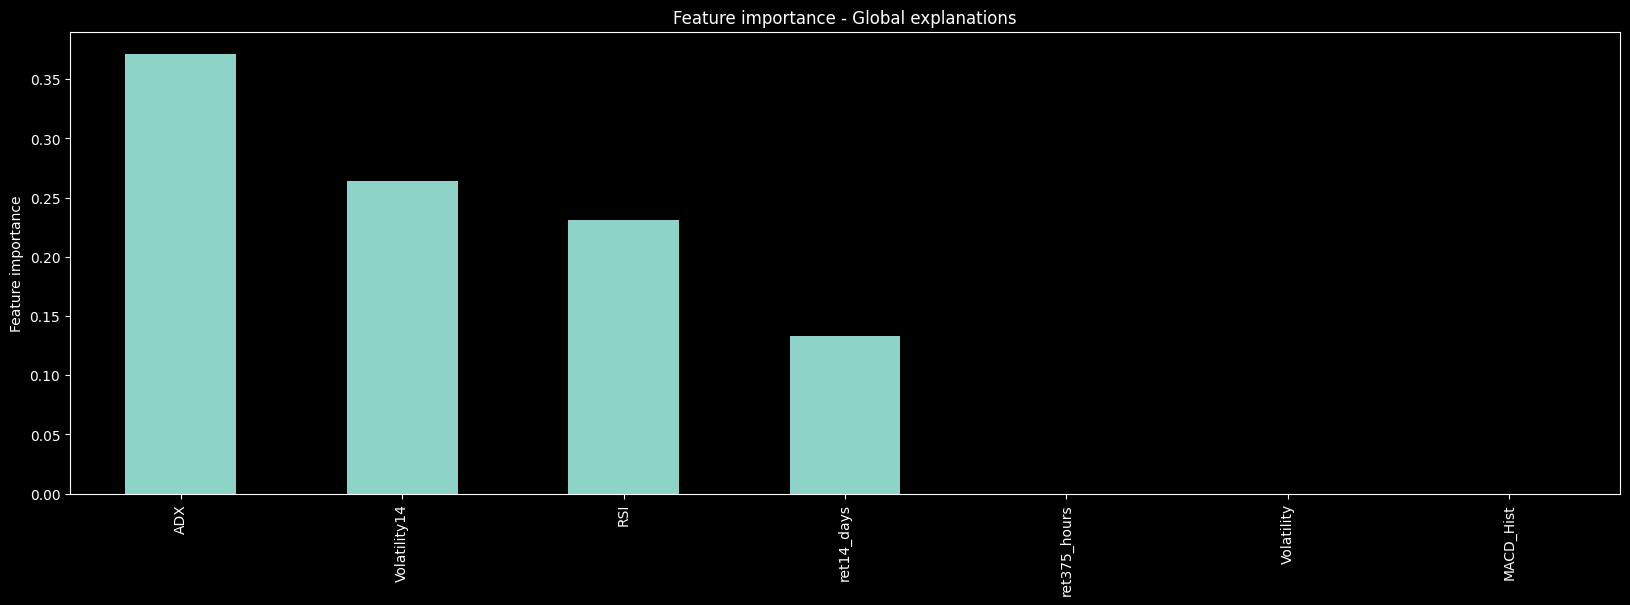

In [31]:
global_exp = pd.Series(
    surrogate.feature_importances_,
    index=surrogate.feature_names_in_)

global_exp.sort_values(ascending=False).plot.bar(figsize=(20,6))
plt.ylabel("Feature importance")
plt.title("Feature importance - Global explanations")
plt.show()

In [32]:
c_test[0:20]

array([5, 5, 0, 0, 0, 5, 5, 5, 5, 0, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0])

In [33]:
# obtain data for first observation

prediction, bias, contributions = ti.predict(surrogate, df_test.head(1))

In [34]:
# for observation 1, the probability of being allocated to each cluster

prediction[0]

array([0.87219382, 0.        , 0.        , 0.        , 0.03378529,
       0.07379418, 0.00800178, 0.01222494, 0.        ])

In [35]:
# contributions towards being allocated in cluster 0

c = contributions[0][:,0]

c

array([0.        , 0.04452441, 0.        , 0.16373824, 0.22130788,
       0.21914284, 0.        ])

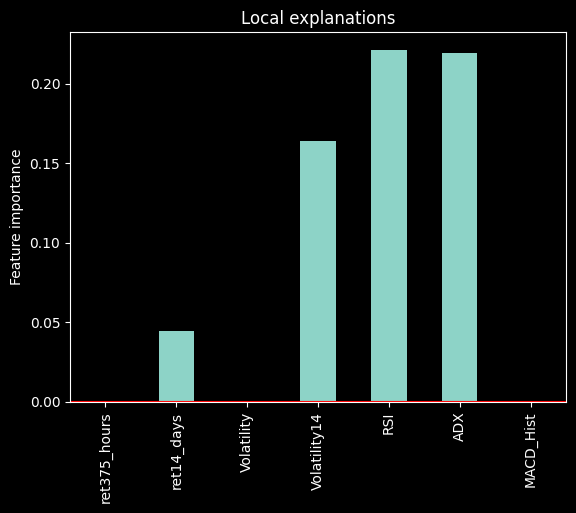

In [36]:
pd.Series(c, index=df_train.columns).plot.bar()
plt.axhline(y=0, color='r', linestyle='-')
plt.ylabel("Feature importance")
plt.title("Local explanations")
plt.show()

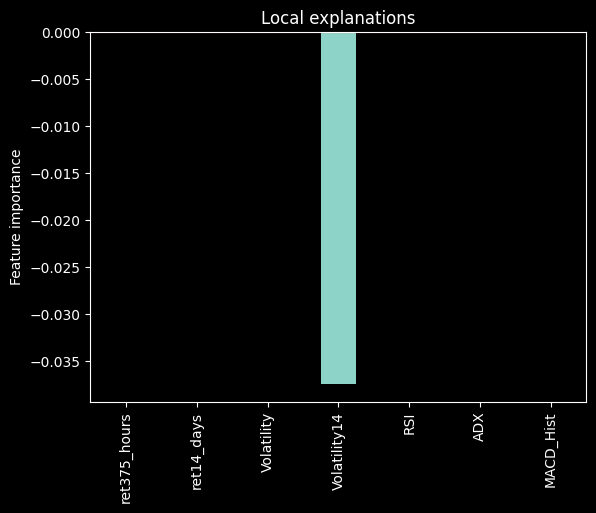

In [37]:
# contributions towards not being allocated in cluster 1

c = contributions[0][:,1]

pd.Series(c, index=df_train.columns).plot.bar()
plt.axhline(y=0, color='r', linestyle='-')
plt.ylabel("Feature importance")
plt.title("Local explanations")
plt.show()

### Trading Strategy

In this strategy, we first use K-Means clustering to group historical data into distinct clusters based on various technical features. Then, for each cluster, we compute the skewness of future returns (measured by percentage change in price over a defined period) to assess the risk-reward profile of each group. By examining the distribution of future returns for each cluster, we can identify clusters that show promising skewness (e.g., positive skew indicating potential upside) then go long and short the clusters with negative skew (indicating a higher likelihood of negative returns). This can guide decision-making in positioning trades based on expected return distributions for each cluster.

In [38]:
# Getting the cluster for each observation in the train data set
df_train["cluster"] = model.predict(df_train)

# Getting the cluster for each observation in the test data set
df_test["cluster"] = model.predict(df_test)

# Add fut_ret to df
time_prd = 15
df_train['fut_ret'] = data['close'].pct_change(time_prd).shift(-time_prd).reindex(df_train.index)
df_test['fut_ret'] = data['close'].pct_change(time_prd).shift(-time_prd).reindex(df_test.index)

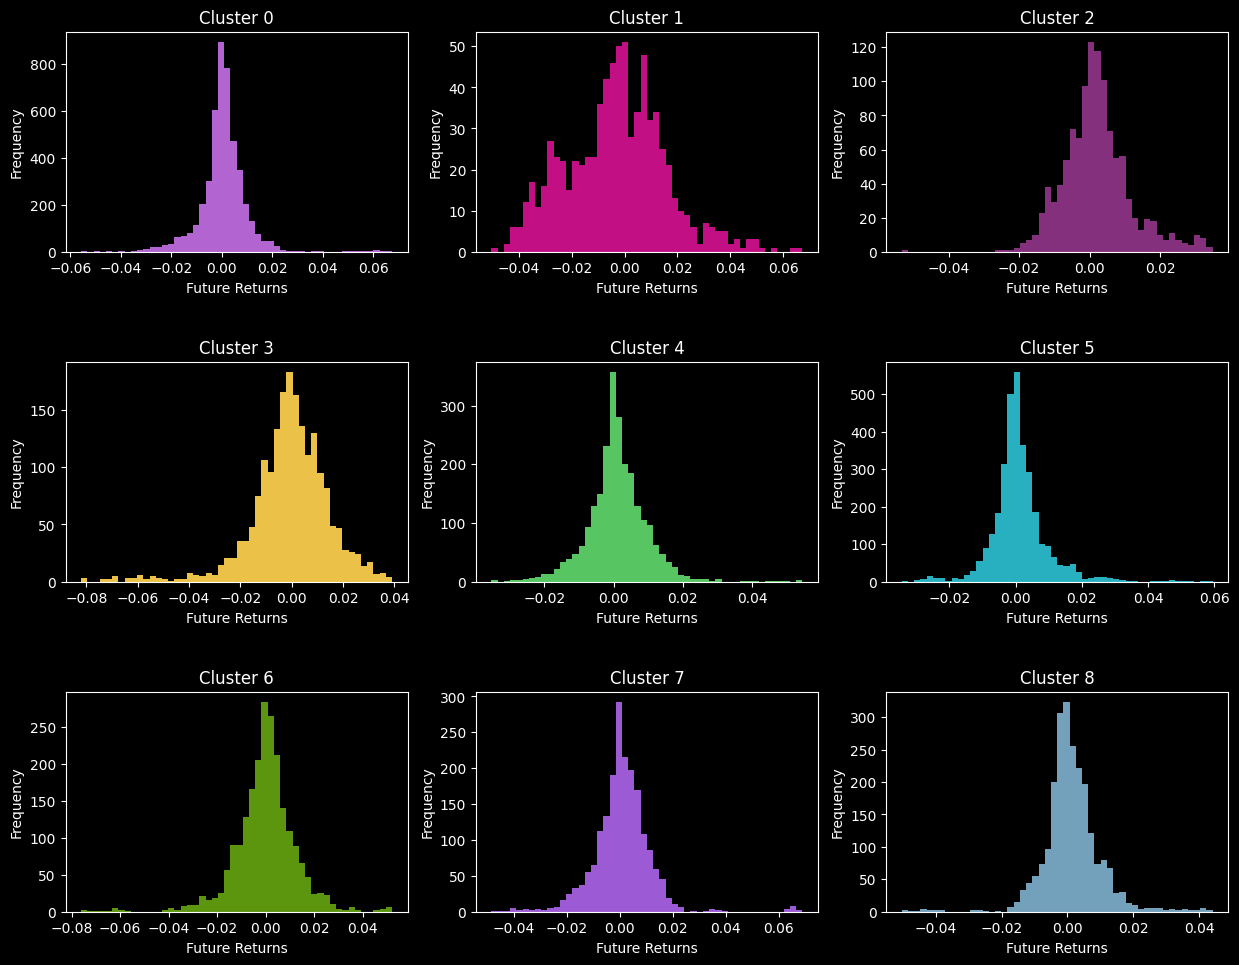

In [45]:
# Plotting distribution of future returns for each cluster
row = int(num_clusters / 2) + 1
col = 3

for cluster in range(num_clusters):
    plt.subplot(row, col, cluster + 1)
    plt.title(f"Cluster {cluster}")
    df_train[df_train["cluster"] == cluster]["fut_ret"].plot(
        kind='hist', figsize=(15, 20), bins=50, **{"color": [np.random.random(3)]})
    plt.xlabel("Future Returns")

# Adjust spacing between plots
plt.subplots_adjust(hspace=0.5)  # Increase the vertical spacing

plt.show()

Skewness is a metric that measures how stretched a distribution is to the left or right. A negatively skewed distribution is stretched to the left, while a positively skewed distribution is stretched to the right. Skewness also highlights the concentration of data points at either end, with fat tails indicating more observations on one side.

The table below provides a guide to interpreting skewness:
| Type | Value Range |
| --- | --- |
| Symmetric | -0.5 to 0.5 |
| Moderately Negatively Skewed | -1 to -0.5 |
| Moderately Positively Skewed | 0.5 to 1 |
| Highly Negatively Skewed | < -1 |
| Highly Positively Skewed | > 1 |

Our goal is to focus on fat-tail events, so we’ll trade only the clusters that show extreme skewness—either positively or negatively skewed. We will use the skewness property of a pandas DataFrame to guide our decisions:

* **Go long** on any cluster with **skewness greater than 0.75**. Since Apple is generally predicted to increase, we will take a more aggressive stance on the long side.
  
* **Go short** on any cluster with **skewness less than -1**. We’ll be more conservative with short positions, given the higher risk.
  
* **Remain neutral** or take no position on clusters with skewness between **-1 and 0.75**, as they are considered more balanced and unlikely to show extreme returns.
  
This strategy aims to capitalize on clusters with fat tails by focusing on extreme positive and negative skewness for making trading decisions.

In [40]:
# Define a dataframe to store percentage of number of positive returns and negative returns
clusters = pd.DataFrame(columns=[
                        "cluster_number", "skewness", "direction"])

# Adding cluster numbers
clusters["cluster_number"] = [i for i in range(num_clusters)]

# Calculating number of positive and negative returns and adding them to
# clusters dataframe
for cluster_number in clusters["cluster_number"]:
    # Cluster dataframe for training dataset
    fut_returns = df_train[df_train["cluster"] == cluster_number]

    # Calculating skewness
    skewness = fut_returns["fut_ret"].skew()

    # Adding percentage of positive trades
    clusters.loc[cluster_number, "skewness"] = round(skewness, 2)

# Adding direction based on the rules - 1 for long, 0 for neutral, -1 for short
clusters["direction"] = 0
clusters["direction"] = np.where(
    clusters["skewness"] > 0.75, 1, clusters["direction"])
clusters["direction"] = np.where(
    clusters["skewness"] < -1.0, -1, clusters["direction"])

clusters.head(10)

,cluster_number,skewness,direction
0,0,0.81,1
1,1,0.25,0
2,2,0.51,0
3,3,-1.15,-1
4,4,0.47,0
5,5,1.23,1
6,6,-0.63,0
7,7,1.0,1
8,8,0.07,0


Next, we examine the mean feature values for each cluster. Notably, our buy signal clusters—0, 5, and 7—share similar mean values across key features. Meanwhile, Cluster 3, which generated a short signal, exhibits an elevated Volatility14 mean value.

Interestingly, Cluster 1 also has a high Volatility14 mean but only shows 0.25 positive skew, which is not extreme enough to trigger a trade. This suggests that Cluster 1 may warrant further analysis, as it could potentially be split into a separate cluster to capture more nuanced market behavior.

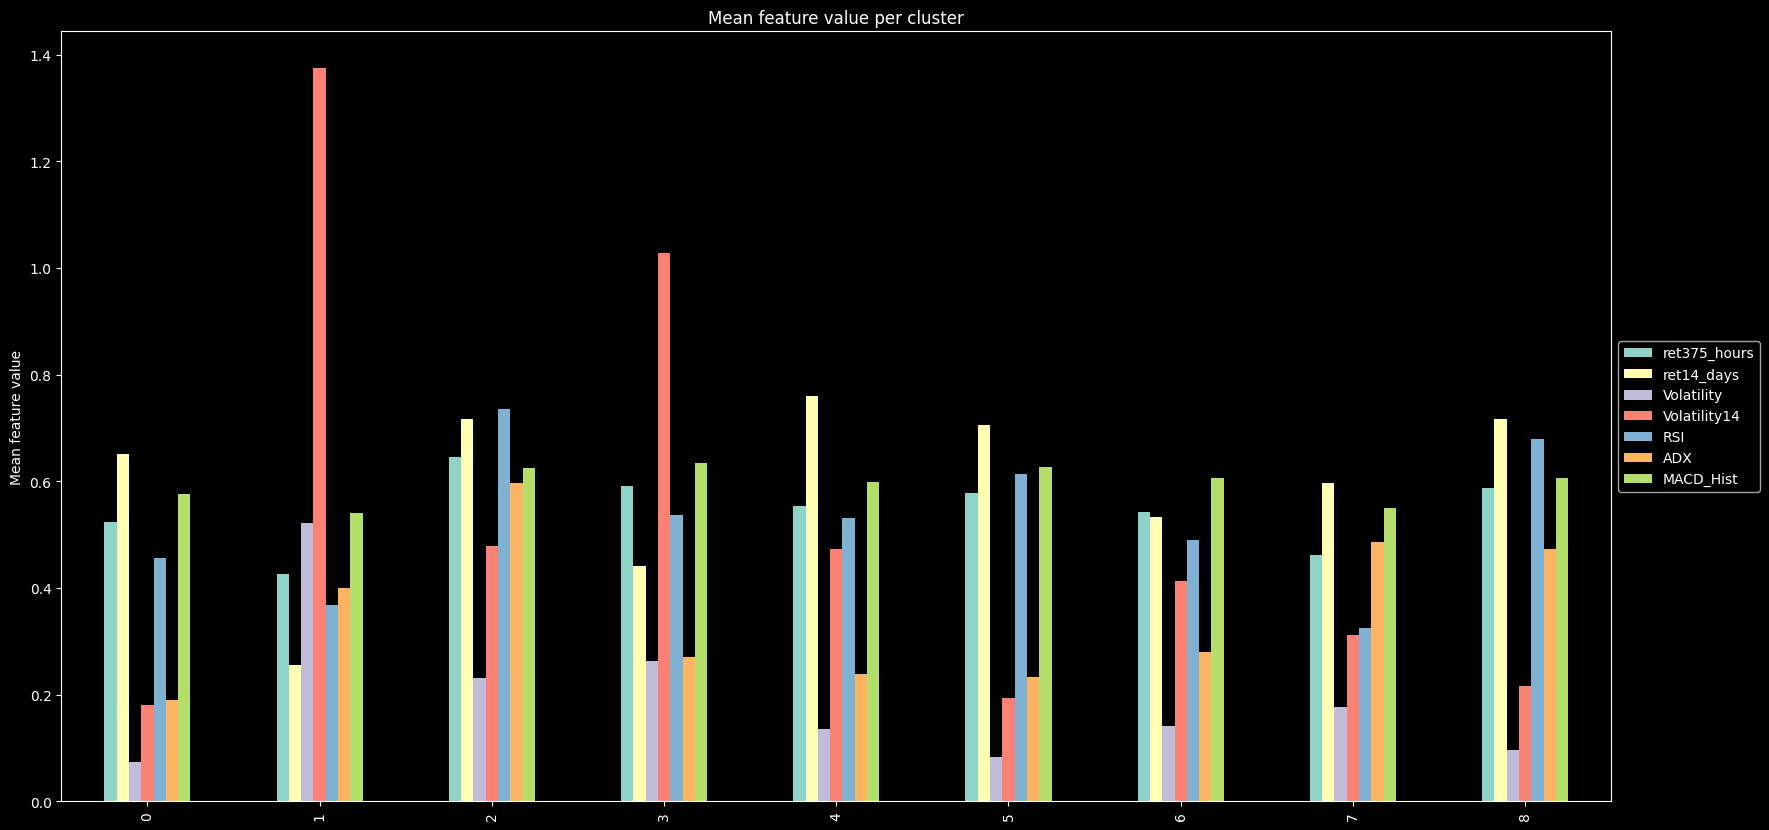

In [41]:
s = df_test.drop(columns=['fut_ret', 'cluster']).groupby(c_test).mean()

# Plotting
s.plot.bar(figsize=(20, 10))
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.title("Mean feature value per cluster")
plt.ylabel("Mean feature value")
plt.show()

### Backtest and Evaluation Metrics

We add the trade direction columns to our test dataset.

In [42]:
# Adding the direction column to the test dataset based on the clusters dataframe
df_test["direction"] = df_test["cluster"].apply(
    lambda cluster: clusters[clusters["cluster_number"] ==
                             cluster]["direction"].iloc[0])

df_test.head()

,ret375_hours,ret14_days,Volatility,Volatility14,RSI,ADX,MACD_Hist,cluster,fut_ret,direction
date,,,,,,,,,,
2019-04-10 13:45:00,0.594263,0.608181,0.073024,0.263678,0.536892,0.271213,0.641751,5,0.002350,1
2019-04-10 14:00:00,0.573843,0.604461,0.072143,0.263829,0.510875,0.260714,0.639076,5,0.002653,1
2019-04-10 14:15:00,0.556498,0.594414,0.071517,0.263188,0.487897,0.253315,0.630757,0,0.002105,1
2019-04-10 14:30:00,0.550502,0.601124,0.069644,0.262665,0.495662,0.244895,0.626131,0,0.002254,1
2019-04-10 14:45:00,0.547841,0.600976,0.069511,0.262662,0.501313,0.235769,0.623512,0,0.003105,1


We will backtest the trading strategy by multiplying the trade direction by the daily returns, then compare its performance against a **buy-and-hold benchmark**.

The results show that our strategy achieves a **106.13% return**, significantly outperforming the **benchmark's ~40% return** over the testing period. The strategy effectively captures most of the **positive returns** while also performing well in shorting during **downtrends**.

Perhaps the most compelling metric is the **Sharpe ratio**—our strategy achieves **2.556**, more than **twice** the buy-and-hold Sharpe ratio of **1.183**. This indicates that the strategy not only delivers **higher returns** but also does so with **lower risk** and **reduced market exposure**.

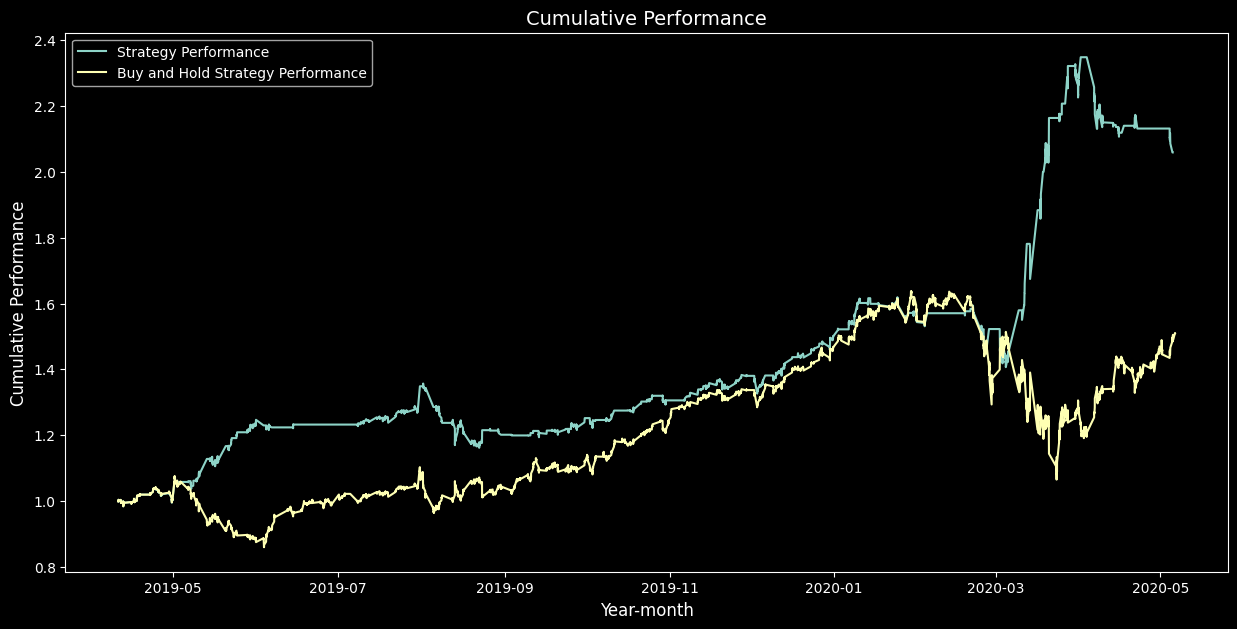

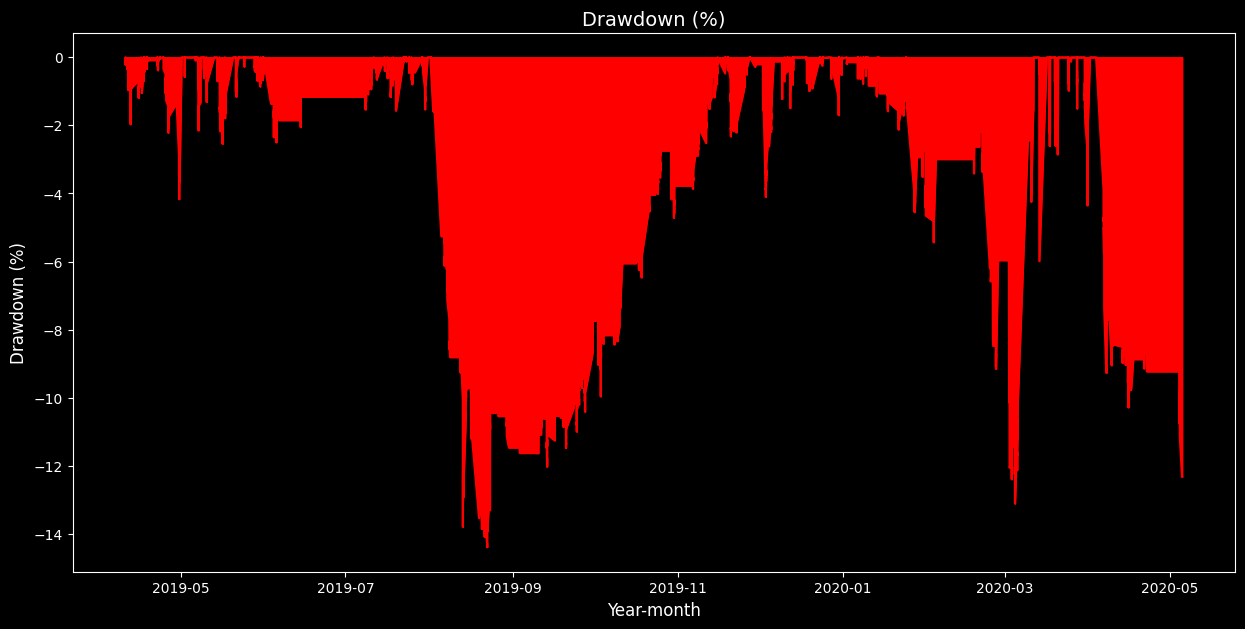

Total returns: 106.13%
Annualised returns (CAGR): 99.28%
Maximum drawdown (MDD): -14.39%
Return-to-MDD ratio: 6.9
Benchmark Sharpe Ratio: 1.183
Strategy Sharpe Ratio: 2.556


In [43]:
def calculate_sharpe_ratio(returns, risk_free_rate=0):
    # Calculate the excess returns (returns above the risk-free rate)
    excess_returns = returns - risk_free_rate
    
    # Calculate the Sharpe ratio
    sharpe_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(252*6.5*4)  # Annualized Sharpe ratio
    return sharpe_ratio

# Add Adj Close back to df_test
df_test['close'] = data['close'].reindex(df_test.index)

# Calculate the buy and hold returns
benchmark_returns = (1 + df_test["close"].pct_change()).cumprod().dropna()

# Calculate the strategy returns
df_test['returns'] = df_test["close"].pct_change() * df_test["direction"].shift(1)

# Calculate the cumulative returns
df_test['cumulative_returns'] = (1 + df_test['returns']).cumprod()

# Drop rows with missing values
df_test.dropna(inplace=True)

# Call the performance analysis function
performance_analysis(df_test['cumulative_returns'], benchmark_returns)

# Calculate Sharpe ratios
benchmark_sharpe = calculate_sharpe_ratio(df_test["close"].pct_change().dropna())
strategy_sharpe = calculate_sharpe_ratio(df_test["returns"].dropna())

print(f"Benchmark Sharpe Ratio: {round(benchmark_sharpe, 3)}")
print(f"Strategy Sharpe Ratio: {round(strategy_sharpe, 3)}")

The analytics show that the straegy took 102 long trades and 62 short trades with a net profit of 189.53.  The winning percentage was 60.98% with an average profit per winning trade of 3.30 and average loss per losing trade of 2.19.

In [44]:
# Trade log
trade_log = get_trades(df_test, "close", "direction")

# Analytics
analytics = get_analytics(trade_log)

analytics

,Strategy
Number of long trades,102.00
Number of short trades,62.00
Total number of trades,164.00
Gross profit,329.53
Gross loss,-140.00
Net profit,189.53
Number of winners,100.00
Number of losers,64.00
Winning percentage,60.98
Losing percentage,39.02


### Future Potential Model and Strategy Improvements

1. Refine Cluster Assignments
* Increase the number of clusters: More granular clusters may capture additional patterns.
  
* Hierarchical Clustering: Instead of K-means, try hierarchical clustering to identify subgroups within each cluster.
  
* Feature Engineering: Add new features like volume spikes, implied volatility, or macroeconomic indicators to improve clustering quality.
  
2. Optimize Trade Signals
* Dynamic Skewness Thresholds: Instead of fixed values (e.g., >0.75 for long, <-1 for short), use adaptive thresholds based on rolling statistics.
  
* Include Kurtosis: Fat tails alone might not be enough—consider kurtosis to capture extreme price movements.
  
* Momentum Confirmation: Require confirmation from momentum indicators (e.g., MACD, moving averages) before entering trades.
  
3. Improve Execution & Risk Management
* Position Sizing: Adjust trade size based on volatility (e.g., use ATR or standard deviation to size positions).
  
* Stop-Loss & Take-Profit: Implement dynamic stop-loss levels based on ATR, volatility, or support/resistance levels.
  
* Max Drawdown Control: Introduce a risk-based filter to stop trading during high drawdown periods.
  
4. Add Regime Detection
* Market Regimes: Use unsupervised learning (e.g., HMM, Gaussian Mixture Models) to detect different market regimes and adjust trading rules accordingly.
  
* Volatility Filters: Only take signals when volatility is within a favorable range (e.g., VIX filtering).
  
5. Enhance Backtesting & Evaluation
* Walk-Forward Optimization: Avoid overfitting by re-evaluating clusters periodically using rolling windows.
  
* Transaction Costs & Slippage: Incorporate realistic trading costs to ensure the strategy remains profitable.
  
* Compare with More Benchmarks: Evaluate against other strategies (e.g., risk-parity, momentum strategies) for a better understanding of its relative performance.